In [273]:
import os
import re
import gc

import numpy as np
from numpy.random import randint, normal, uniform
import pylab as pl
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

from joblib import Parallel, delayed

from astropy import units as u

import healpy as hp
import camb

from ksw import Cosmology, Data, ReducedBispectrum, KSW, Shape
from ksw.radial_functional import radial_func

import h5py

%matplotlib inline

# Data Generator

This code primamrly uses [KSW](https://github.com/AdriJD/ksw/tree/master/src), as a means to generate non-gaussian cmb maps. These get stored in a data file with the fnls, fullsky maps, and patches.

The fullsky maps are generated using the method discussed in [CMB lensing and primordial non-Gaussianity](https://arxiv.org/abs/0905.4732), where we find (eq. 6) 
$$
a_{\ell m} = a_{\ell m}^{{G}} + f_{NL}^X a_{\ell m}{^{NG}}
$$
and generated the full sky map by passing these $a_{\ell m}$ into healpy.

Most of this code is to calculate the term (eq. 27)

$$
a_{\ell m}^{NG,loc'} = \int dr r^2 \left[ \alpha_\ell(r)\left(\int d^2 \hat{n} Y_{\ell m}^\star (\hat{n}) B(r,\hat{n})^2 \right)\right]
$$

and

$$
\alpha_\ell(r)=\frac{2}{\pi} \int_0^\infty dk k^2 \Delta_\ell^T(k) j_\ell(k r)
$$

$$
\beta_\ell(r)=\frac{2}{\pi} \int_0^\infty dk k^{-1} \Delta_\phi \Delta_\ell^T(k) j_\ell(k r)
$$

$$
B(r, \hat{n}) = \sum_{\ell,m} \frac{\beta_\ell (r)}{C_\ell} a_{\ell m} Y_{\ell m}
$$

where $\Delta_\phi$ is pridormial normalization, $\Delta_\ell^T(k)$ is the transfer function, $j_\ell(k r)$ are the spherical bessel functions

---

## Settings

See: https://camb.readthedocs.io/en/latest/model.html

Some values are forced during init of ksw.Cosmology. 
For an example on how to modify these values after init: https://github.com/AdriJD/ksw/blob/fba3250cfe4c5145b5db12fa54bbc54bbcf5a56c/tests/python/test_cosmology.py#L65

In [274]:
cosmo_params = {
    'H0': 67.5,
    'r': 0,
    'As': 2.13e-09,
    'ns': 0.9624,
    'pivot_scalar': 0.05,
    'ombh2': 0.02233,
    'omch2': 0.1198,
    'mnu': 0.06,
    'tau': 0.0561,
    'TCMB': 2.7255,
    'max_l': 3000,

    'lmax': 2000,
    'lens_potential_accuracy': 4,


    ## These are forced by ksw
    "DoLateRadTruncation": False,
    "AccuracyBoost":2.,
    # "BessIntBoost": 30.,
    # "KmaxBoost": 3.,
    # "IntTolBoost": 4.,
    # "TimeStepBoost": 4.,
    # "SourcekAccuracyBoost": 5.,
    # "BesselBoost": 5.,
    # "IntkAccuracyBoost": 5.,
    "lSampleBoost": 2.,
    "lAccuracyBoost": 2.,
    # "AccurateBB": True,
}
lmax=cosmo_params['lmax']

camb_params_obj = camb.set_params(**cosmo_params)
print(camb_params_obj)

class: <CAMBparams>
 WantCls = True
 WantTransfer = False
 WantScalars = True
 WantTensors = False
 WantVectors = False
 WantDerivedParameters = True
 Want_cl_2D_array = True
 Want_CMB = True
 Want_CMB_lensing = True
 DoLensing = True
 NonLinear = NonLinear_lens
 Transfer: <TransferParams>
   high_precision = False
   accurate_massive_neutrinos = False
   kmax = 0.9
   k_per_logint = 0
   PK_num_redshifts = 1
   PK_redshifts = [0.0]
 want_zstar = False
 want_zdrag = False
 min_l = 2
 max_l = 3000
 max_l_tensor = 600
 max_eta_k = 72000.0
 max_eta_k_tensor = 1200.0
 ombh2 = 0.02233
 omch2 = 0.1198
 omk = 0.0
 omnuh2 = 0.000644866570625114
 H0 = 67.5
 TCMB = 2.7255
 YHe = 0.2458384128277519
 num_nu_massless = 2.0293333333333337
 num_nu_massive = 1
 nu_mass_eigenstates = 1
 share_delta_neff = False
 nu_mass_degeneracies = [1.0146666666666666]
 nu_mass_fractions = [1.0]
 nu_mass_numbers = [1]
 InitPower: <InitialPowerLaw>
   tensor_parameterization = tensor_param_rpivot
   ns = 0.9624
   nr

lmax >= 300 is enforced by the ksw code due to errors with CAMB. 
lmax needs to be somewhat smaller then max_l, if you get errors about c_ell change these.
You will get warning messages if lmax > 4\* nside.  

nside should be of type 2\*\*n

num_patches should be even.

patch_side_deg \* num_patches \<\= 180, patch_side_deg \<\= 45; or you will overlap patches 

r_max is given in Mpc, we preform r_res slices over this volume to do the integral. Values have been picked by guestimation, with r_res being set low to help test. Will want to raise this for better calculations.

KSW only supports polarization values of 'T', 'E', ['T', 'E'].

In [275]:
fnl_range=(-1000, 1000)

nsims = 10
npatches = 10                # number of patches to generate per sim
save_size = 10               # save every n sims, helps control memory usage

nside=512

patch_side_deg = 10

r_res = 1000                  # number of slices in the radius, memory and time are greatly impacted by this
r_batch = 10                 # number of slices to compute per thread, memory usage is greatly impacted by this

r_min = 1                    # Mpc, min radius for the patch, >1e-6, but I've had issues below 1 with kernel crashes, check if this should be higher       
r_max = 20000                # Mpc, max radius for the patch, should be > SLS distance, check this value

# KSW only supports 'T' and 'E', need to check 'E' Support
# more testing needs to be done with TE
# polarizations = 'T'
polarizations = ['T', 'E']

# FWHM of gaussian beam, use astropy units to make thing easy here
beam_width = 1 * u.arcmin # type: ignore

# noise settings, for the noise covariance matrix (without beam) in uK^2.
noise_loc = 0
noise_scale = 44 * 1e-12

# not fully tested
lensing = True

# should we save the full sky maps, or just the patches
save_fullsky = True

# For easy switching between notebook and slurm
debug = True


We set the file name best on settings, this will let us load in the data better and ensure we know what settings we are dealing with

In [276]:
if isinstance(polarizations, str):
    chars_of_polarizations = polarizations
elif isinstance(polarizations, list):
    chars_of_polarizations = ''.join(polarizations)
else:
    raise TypeError("polarizations must be either a string or a list of strings")

base_name = f'{nside}_{chars_of_polarizations}_{nsims}x{npatches}_fnl{fnl_range[0]}-{fnl_range[1]}'
data_dir = f'data/ksw' + ('/lensed' if lensing else '/unlensed')
filename = f'{base_name}.hdf5.nc'
data_file = os.path.join(data_dir, filename)

print(f'running sims for {data_dir}/{base_name}')

running sims for data/ksw/lensed/512_TE_10x10_fnl-1000-1000


In [277]:
if not os.path.exists(data_dir): 
    os.makedirs(data_dir)
    print(f'Created directory {data_dir}')
else:
    print(f'Reusing directory {data_dir}')
    pattern = re.compile(f"{base_name}\.hdf5(\.nc)?")
    for file in os.listdir(data_dir):
        if pattern.match(file):
            file_path = os.path.join(data_dir, file)
            os.remove(file_path)
            print(f"Deleted existing data file: {file_path}")

Reusing directory data/ksw/lensed
Deleted existing data file: data/ksw/lensed/512_TE_10x10_fnl-1000-1000.hdf5


In [278]:
npol = 1 if isinstance(polarizations, str) else len(polarizations)
pol_b = npol > 1

nell = lmax + 1
nelem = hp.Alm.getsize(lmax)
npix = hp.nside2npix(nside)
ells = np.arange(nell)

alm_ls, alm_ms = hp.Alm.getlm(lmax)

print(npol, pol_b, nell, alm_ls.shape, alm_ms.shape, npix)

2 True 2001 (2003001,) (2003001,) 3145728


In [279]:
# np.split didnt do what I wanted
def split_into_batches(data, batch_size):
    batches = []
    indices = []
    
    # number of complete batches
    num_batches = len(data) // batch_size
    
    for i in range(num_batches):
        batches.append(data[i*batch_size:(i+1)*batch_size])
        indices.append(np.arange(i*batch_size, (i+1)*batch_size))
    
    # if there are leftover elements
    if len(data) % batch_size != 0:
        batches.append(data[num_batches*batch_size:])
        indices.append(np.arange(num_batches*batch_size, len(data)))
        
    return indices, batches

radii = np.linspace(r_min, r_max, r_res)
dr = radii[1] - radii[0]

sim_idxs, sim_slices = split_into_batches(np.arange(nsims), save_size)
radii_idxs, radii_slices = split_into_batches(radii, r_batch)

print(dr, len(sim_slices), len(radii_idxs), len(radii_slices))

20.01901901901902 1 100 100


In [280]:
# Order for pol_b is TT,EE,TE
noise_ell = normal(noise_loc, noise_scale, (3, nell) if pol_b else (nell))

beam_ell = hp.gauss_beam(beam_width.to_value(u.radian), lmax, pol_b)
if pol_b:
    beam_ell = beam_ell[:,:npol].swapaxes(0,1)

## Simulate the patches

In [281]:
cosmo = Cosmology(camb_params_obj, verbose=debug)

# Additional settings here, i.e.
# cosmo._setattr_camb('ns', 0.9624, subclass='InitPower')

cosmo.compute_transfer(cosmo_params['max_l'])

cosmo.compute_c_ell()

loc = Shape.prim_local(ns=cosmo_params['ns'], pivot=cosmo_params['pivot_scalar'])
cosmo.add_prim_reduced_bispectrum(loc, radii)

Updated CAMB param: BessIntBoost from 1.0 to 30.
Updated CAMB param: KmaxBoost from 1.0 to 3.
Updated CAMB param: IntTolBoost from 1.0 to 4.
Updated CAMB param: TimeStepBoost from 1.0 to 4.
Updated CAMB param: SourcekAccuracyBoost from 1.0 to 5.
Updated CAMB param: BesselBoost from 1.0 to 5.
Updated CAMB param: IntkAccuracyBoost from 1.0 to 5.
Updated CAMB param: AccurateBB from False to True.


In [282]:
data = Data(lmax, noise_ell, beam_ell, polarizations, cosmo)

alm = data.compute_alm_sim(lensing)

pre = '' if lensing else 'un'
c_ells = data.cosmology.c_ell[pre+'lensed_scalar'] # type: ignore

tr_ell_k = data.cosmology.transfer['tr_ell_k']
tr_ells = data.cosmology.transfer['ells']
tr_k = data.cosmology.transfer['k']

mask = (tr_ells < lmax)
tr_ell_k = tr_ell_k[mask]
tr_ells = tr_ells[mask]

print(alm.shape, tr_ell_k.shape, tr_ells.shape, tr_k.shape)

(2, 2003001) (126, 32896, 2) (126,) (32896,)


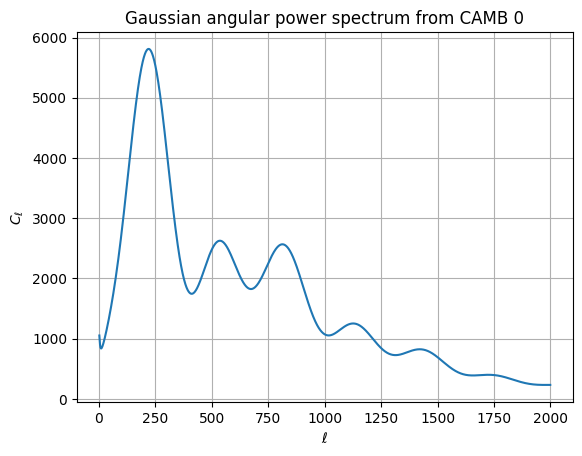

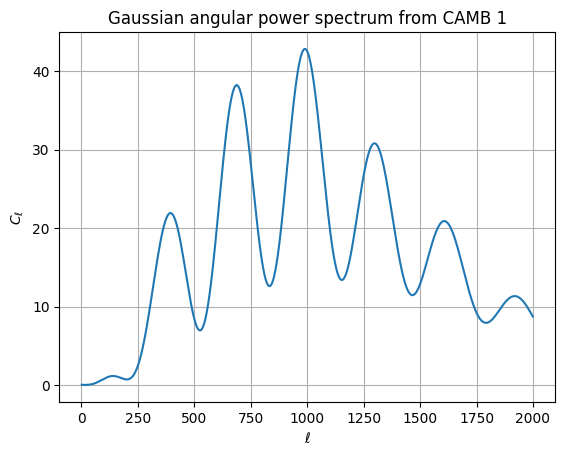

In [283]:
if debug:
    camb_cls = c_ells['c_ell'][2:lmax]
    camb_ls = np.arange(2, lmax)
    for p in range(npol):
        plt.figure()
        plt.plot(camb_ls, camb_ls * (camb_ls + 1) / 2 / np.pi * camb_cls[:,p])
        plt.xlabel("$\ell$")
        plt.ylabel("$C_{\ell}$")
        plt.title(f"Gaussian angular power spectrum from CAMB {p}")
        plt.grid()
        plt.show()

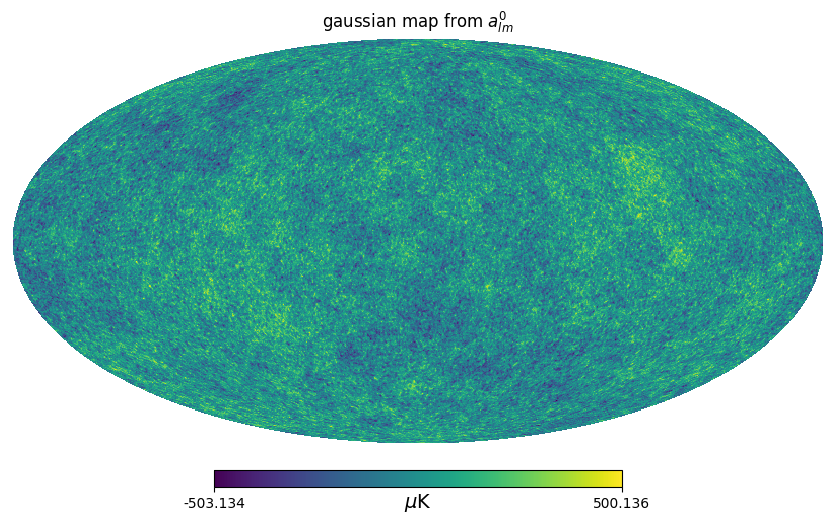

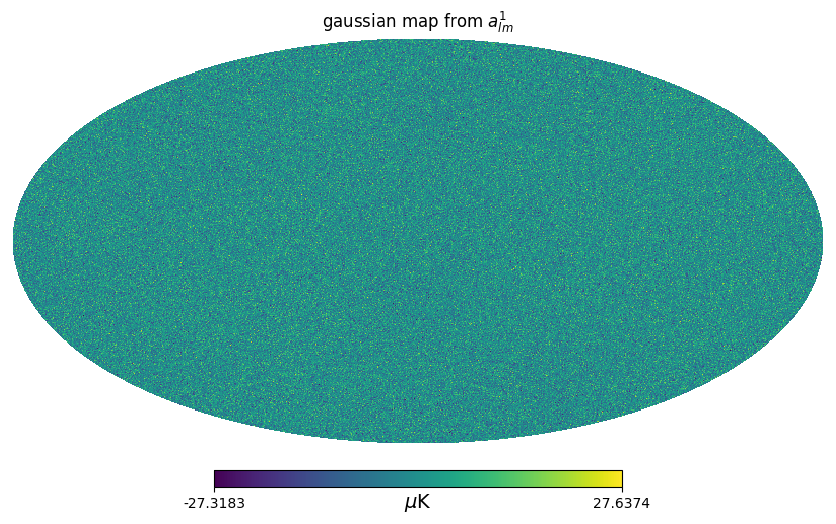

In [284]:
if debug:
    for p in range(npol):
        gaussian_map = hp.alm2map(alm[p], nside=nside, lmax=lmax, pol=pol_b)
        hp.mollview(gaussian_map, title='gaussian map from $a_{lm}^%i$'%(p), unit='$\mu$K')

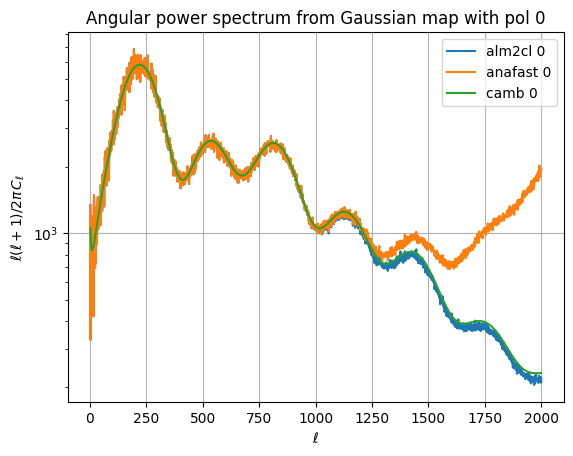

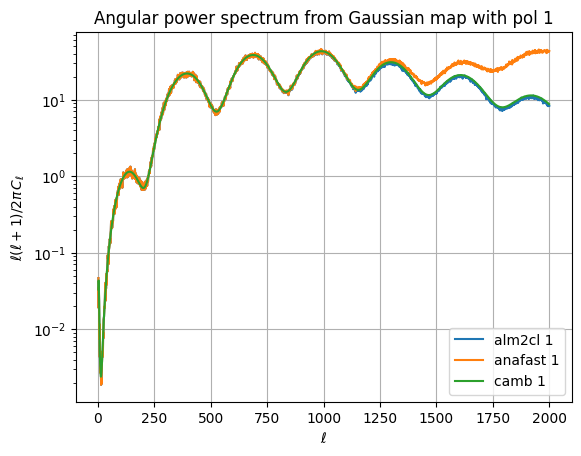

In [300]:
if debug:
    for p in range(npol):
        plt.figure()
        gaussian_map = hp.alm2map(alm[p], nside=nside, lmax=lmax, pol=pol_b)
        cl1 = hp.anafast(gaussian_map, lmax=lmax, pol=pol_b, use_pixel_weights=True)
        cl2 = hp.alm2cl(alm[p], lmax=lmax)
        ell = np.arange(len(cl1))

        scale = (ell * (ell + 1) / 2 / np.pi)

        plt.semilogy(ell[2:], scale[2:] * cl2[2:], label=f'alm2cl {p}')
        plt.semilogy(ell[2:], scale[2:] * cl1[2:], label=f'anafast {p}')
        plt.semilogy(camb_ls, camb_ls * (camb_ls + 1) / 2 / np.pi * camb_cls[:,p], label=f'camb {p}')

        plt.xlabel("$\ell$")
        plt.ylabel("$\ell(\ell+1)/2\pi\,C_{\ell}$")
        plt.title(f'Angular power spectrum from Gaussian map with pol {p}')
        plt.legend()
        plt.grid()
        plt.show()

`radial_func` computes $f_\ell^X(r) = \frac{2}{\pi} \int k^2 dk f(k) \Delta^{TX}_\ell(k) j_\ell(k r)$, we will use this to find 
$
\alpha_\ell(r)=\frac{2}{\pi} \int_0^\infty dk k^2 \Delta_\ell^T(k) j_\ell(k r)
$
and
$
\beta_\ell(r)=\frac{2}{\pi} \int_0^\infty dk k^{-1} \Delta_\phi \Delta_\ell^T(k) j_\ell(k r)
$. 

$\Delta_\ell^T(k)$, the transfer functions, are calculated sparsely by CAMB; We thus need to interpolate over the missing values to get `alpha_l`, `beta_l` which are suitable for the calculations. We do this with `CubicSpline`, but this could be changed if needed. We also go ahead and calculate `bl_div_cl`=$\beta_\ell / C_\ell$, which is used to calculate $B(r,\hat{n})$.

In [286]:
def interpolate_ells(func, ells_sparse, ls):
    return CubicSpline(ells_sparse, func, axis=1)(ls)

delta_phi = (2 * np.pi) * cosmo_params['As'] * np.sqrt(3 / 5)

f_k = np.ones((len(tr_k), 2), dtype=float)
# f_k[:, 0] = 1                         # f_k for alpha
f_k[:, 1] = (tr_k**-3 * delta_phi)      # f_k for beta

rad = radial_func(f_k, tr_ell_k, tr_k, radii, tr_ells)

alpha_ell = rad[:,:,:,0]
alpha_l = np.concatenate(np.array([interpolate_ells(alpha_ell, tr_ells, ells)]))
alpha_l = np.ascontiguousarray(alpha_l)

beta_ell = rad[:,:,:,1]
c_ells_new = c_ells['c_ell'][tr_ells, :npol]
div = beta_ell / c_ells_new[np.newaxis, :, :]

bl_div_cl = np.concatenate(np.array([interpolate_ells(div, tr_ells, ells)]))
bl_div_cl = np.ascontiguousarray(bl_div_cl)

print(alpha_l.shape, bl_div_cl.shape)

(1000, 2001, 2) (1000, 2001, 2)


$$
B(r, \hat{n}) = \sum_{\ell,m} \frac{\beta_\ell (r)}{C_\ell} a_{\ell m} Y_{\ell m}
$$

$$
a_{\ell m}^{NG,loc'} = \int dr r^2 \left[ \alpha_\ell(r)\left(\int d^2 \hat{n} Y_{\ell m}^\star (\hat{n}) B(r,\hat{n})^2 \right)\right]
$$

In [287]:
def get_alm_ng_slice():
    for p in range(npol):
        for r_idxs, rs in zip(radii_idxs, radii_slices):
                yield bl_div_cl[r_idxs,:,p], alpha_l[r_idxs,:,p], rs, p

def alm_ng_slice(dr, nside, lmax, pol_b, alm, bl_div_cl, alpha_l, radii):
    # is it okay to have pol=False here??
    
    Balm = np.array([ hp.almxfl(alm, bl_div_cl[i]) for i in range(len(radii)) ])
    B = hp.alm2map(Balm, nside=nside, lmax=lmax, pol=False)

    # Error encountered at /project/healpixsubmodule/src/cxx/Healpix_cxx/alm_healpix_tools.cc, line 57
    # (function void map2alm(const Healpix_Map<T>&, Alm<std::complex<_Tp> >&, const arr<double>&, bool) [with T = double])
    # map contains undefined pixels
    # terminate called after throwing an instance of 'PlanckError'
    inner = hp.map2alm(B**2, lmax=lmax, pol=False)

    alm_ng = np.array([dr * radii[i]**2 * hp.almxfl(inner[i], alpha_l[i]) for i in range(len(radii))])   
    return np.sum(alm_ng, axis=0) # type: ignore
        
alm_ng = Parallel(n_jobs=-1, verbose=1)(delayed(alm_ng_slice)(dr, nside, lmax, pol_b, alm[p], bldivcls, alphals, rs) # type: ignore
                for bldivcls, alphals, rs, p in get_alm_ng_slice())

alm_ng = np.reshape(alm_ng, (npol, len(radii_slices), alm.shape[1]))
alm_ng = np.sum(alm_ng, axis=1)
alm_ng = np.ascontiguousarray(alm_ng)

print(alm_ng.shape)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  5.0min
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:  6.8min finished


(2, 2003001)


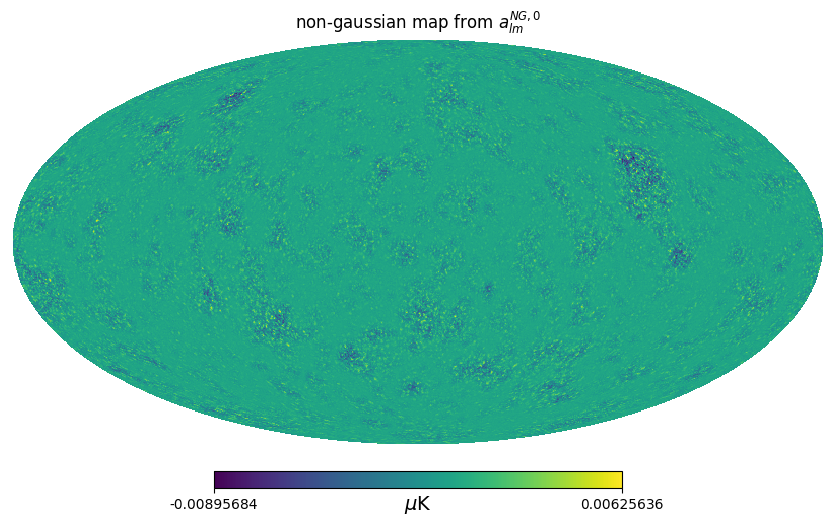

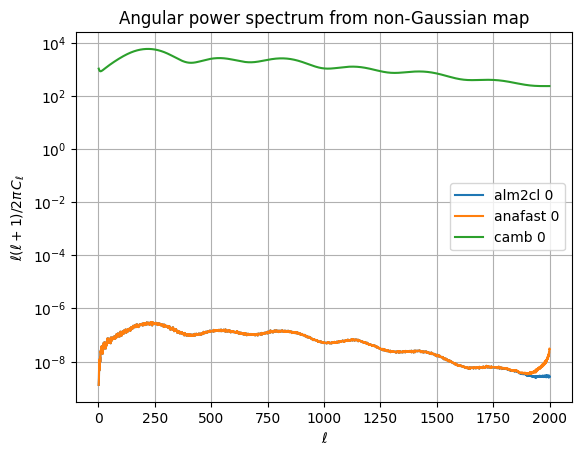

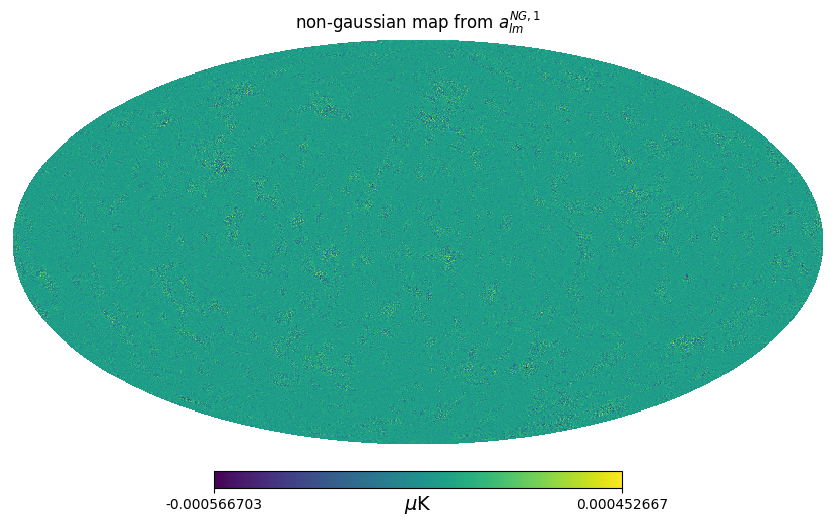

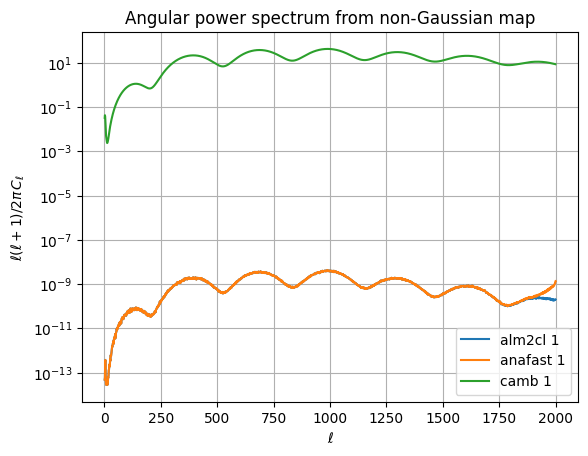

In [302]:
if debug:
    for p in range(npol):
        ng_map = hp.alm2map(alm_ng[p], nside=nside, lmax=lmax)
        hp.mollview(ng_map, title='non-gaussian map from $a_{lm}^{NG,%i}$'%(p), unit='$\mu$K')
        plt.show()
        
        cl1 = hp.anafast(ng_map, lmax=lmax, use_pixel_weights=True)
        cl2 = hp.alm2cl(alm_ng[p], lmax=lmax)

        scale = ell * (ell + 1) / 2 / np.pi

        plt.semilogy(ells[2:], scale[2:] * cl2[2:], label=f'alm2cl {p}')
        plt.semilogy(ells[2:], scale[2:] * cl1[2:], label=f'anafast {p}')
        plt.semilogy(camb_ls, camb_ls * (camb_ls + 1) / 2 / np.pi * camb_cls[:,p], label=f'camb {p}')

        plt.xlabel("$\ell$")
        plt.ylabel("$\ell(\ell+1)/2\pi\,C_{\ell}$")
        plt.title('Angular power spectrum from non-Gaussian map')
        plt.legend()
        plt.grid()

In [289]:
def cutSqPatches(fullsky_map, img_size, side_deg, num_patches):
    Tmap_datat = np.zeros((num_patches//2, int(img_size), int(img_size)))
    Tmap_datab = np.zeros((num_patches//2, int(img_size), int(img_size)))

    for counter in range(num_patches//2):
        Tmap_datat[counter] = np.ma.getdata(hp.cartview(fullsky_map, 
                                                            fig=0, 
                                                            xsize=img_size, 
                                                            ysize=img_size, 
                                                            rot=[0, 0], 
                                                            lonra=[side_deg*counter, side_deg*(counter+1)], 
                                                            latra=[0, side_deg],
                                                            title="CartView", 
                                                            unit="mK", 
                                                            format="%.2g", 
                                                            return_projected_map=True))
        
        Tmap_datab[counter] = np.ma.getdata(hp.cartview(fullsky_map, 
                                                            fig=1, 
                                                            xsize=img_size, 
                                                            ysize=img_size, rot=[0, 0], 
                                                            lonra=[side_deg*counter, side_deg*(counter+1)], 
                                                            latra=[-side_deg, 0],
                                                            title="CartView", 
                                                            unit="mK", 
                                                            format="%.2g", 
                                                            return_projected_map=True))
        
    return np.concatenate((Tmap_datat, Tmap_datab))

def append_to_hdf5(file_path, data_dict):
    with h5py.File(file_path, 'a') as f:
        for key, value in data_dict.items():
            # If dataset exists in file, append to it
            if key in f:
                f[key].resize((f[key].shape[0] + value.shape[0]), axis=0)
                f[key][-value.shape[0]:] = value
            else:
                maxshape = (None,) + value.shape[1:]
                dataset = f.create_dataset(key, shape=value.shape, maxshape=maxshape, chunks=True)
                dataset[:] = value 

fnls are generated per sim, so each patch for each sim has the same fnl

In [290]:
fnls = uniform(fnl_range[0], fnl_range[1], nsims).astype(np.float32)
append_to_hdf5(data_file, {'fnls': fnls})

In [291]:
def get_sim_run(sims):
    for p in range(npol):
        for sim in sims:
            yield sim, p

def run_sim(nside, npatches, patch_side_deg, lmax, pol_b, alm, alm_ng, fnl):
    alm_prime = alm + fnl * alm_ng
    # do we have sufficent randomization here?
    # we might need to add a randomized noise alm
    maps = hp.alm2map(alm_prime, nside, lmax=lmax, pol=pol_b)
    patches = cutSqPatches(maps, nside, patch_side_deg, npatches)   
    return (alm_prime, maps, patches)

# beam = lambda alm : alm
# icov_nl = data.icov_diag_nonlensed
# icov_ell = np.ones((1, lmax + 1))
# estimator = KSW(cosmo.red_bispectra, icov_nl, beam, lmax, polarizations)

pl.ioff()
with Parallel(n_jobs=-1, verbose=1) as parallel:
    print(sim_slices)
    for sims in sim_slices:
        sim_data = parallel(delayed(run_sim)(nside, npatches, patch_side_deg, lmax, pol_b, alm[p], alm_ng[p], fnls[sim]) 
            for sim, p in get_sim_run(sims))

        alms = [data[0] for data in sim_data]
        maps = np.array([data[1] for data in sim_data]).reshape(npol, len(sims), npix)
        patches = np.array([data[2] for data in sim_data]).reshape(npol, len(sims), npatches, nside, nside)
        
        # for a in alms:
            # estimator.step(a.copy())
            # fisher = estimator.compute_fisher()
            # ksw = estimator.compute_estimate(alms[:, m].copy())
            # print(fnls[m], fisher, ksw)

        data_dict = {'patches': patches}
        if save_fullsky:
             data_dict['maps'] = maps

        print(f'Saving to {data_file}, patches: {patches.shape}, maps: {save_fullsky} {maps.shape}')
        append_to_hdf5(data_file, data_dict)
    
pl.close('all')
pl.ion()


[array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])]


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.


[Parallel(n_jobs=-1)]: Done  20 out of  20 | elapsed:    3.1s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done  20 out of  20 | elapsed:    3.1s finished


Saving to data/ksw/lensed/512_TE_10x10_fnl-1000-1000.hdf5.nc, patches: (2, 10, 10, 512, 512), maps: True (2, 10, 3145728)


In [292]:
# print('setting up estimator')
# for i in range(10):
#     estimator.step(data.compute_alm_sim(lensing))
#     print('done', i)

# fisher = estimator.compute_fisher()
# for i, a in enumerate(alms):
#     # estimator.step(alms[:, m].copy())
#     ksw = estimator.compute_estimate(a.copy())
#     print(fnls[i], fisher, ksw)

# print('done with sims') 
# print(maps.shape, patches.shape)

In [293]:
os.rename(data_file, data_file.replace('.hdf5.nc', '.hdf5'))
print('Data saved to', data_file.replace('.hdf5.nc', '.hdf5'))

Data saved to data/ksw/lensed/512_TE_10x10_fnl-1000-1000.hdf5


We are done with generation, if we are not debugging lets just exist, mostly so we dont have to remove these lines everytime we convert the notebook to a python script for batch

In [294]:
if not debug:
    print('Done with Generation!')
    exit(0)

---

# Tests

In [295]:
random_indices = [(randint(npol), randint(maps.shape[1]), randint(npatches)) for _ in range(4)]

print(random_indices)

[(1, 9, 7), (1, 1, 3), (1, 9, 0), (1, 5, 4)]


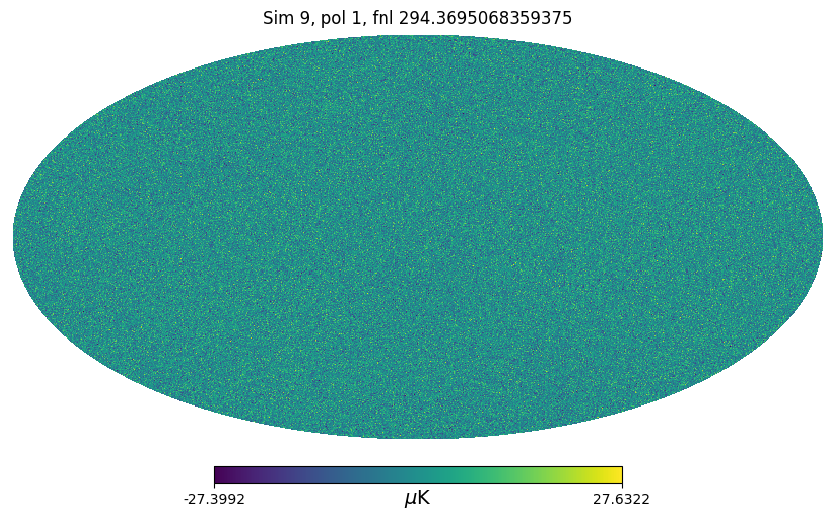

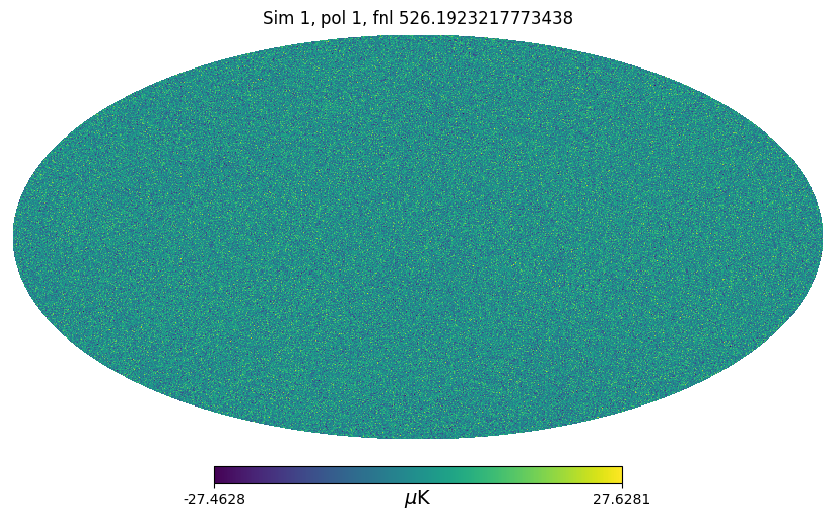

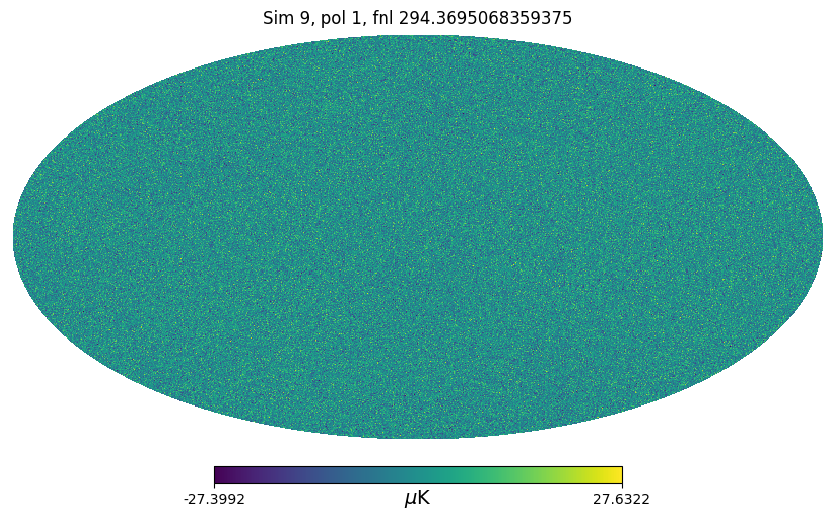

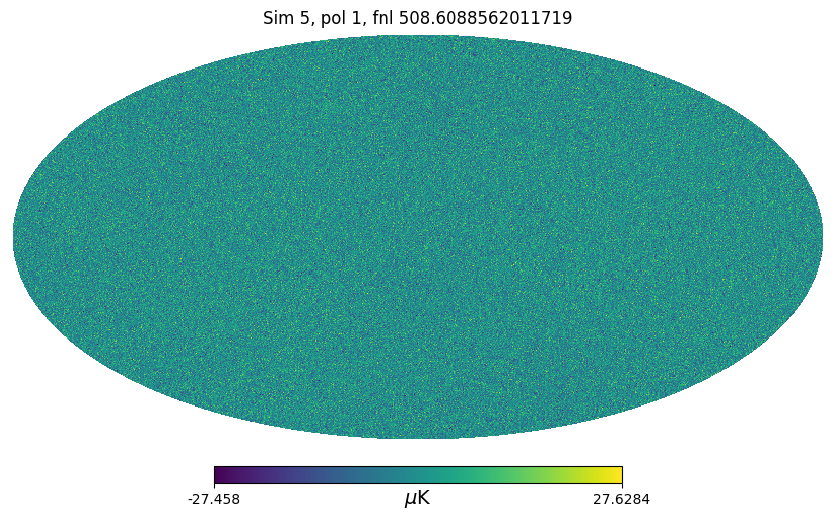

In [296]:
for pol, sim, patch in random_indices:
    hp.mollview(maps[pol, sim], title=f'Sim {sim}, pol {pol}, fnl {fnls[sim]}', unit='$\mu$K')

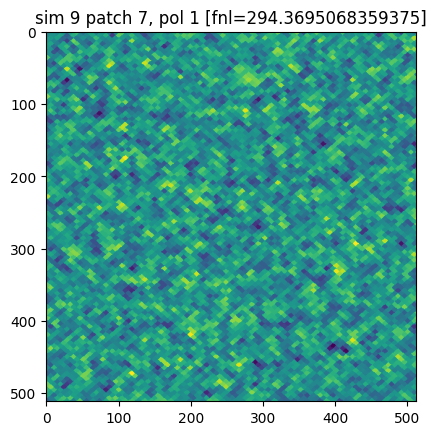

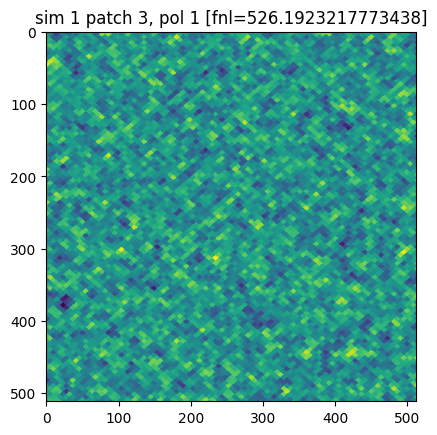

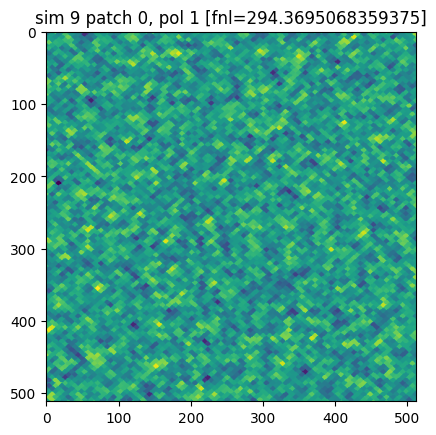

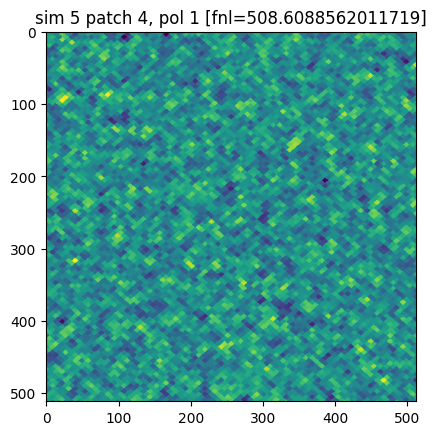

In [297]:
for pol, sim, patch in random_indices:
    plt.figure()
    plt.imshow(patches[pol, sim, patch])
    plt.title(f"sim {sim} patch {patch}, pol {pol} [fnl={fnls[sim]}]")
    plt.show()

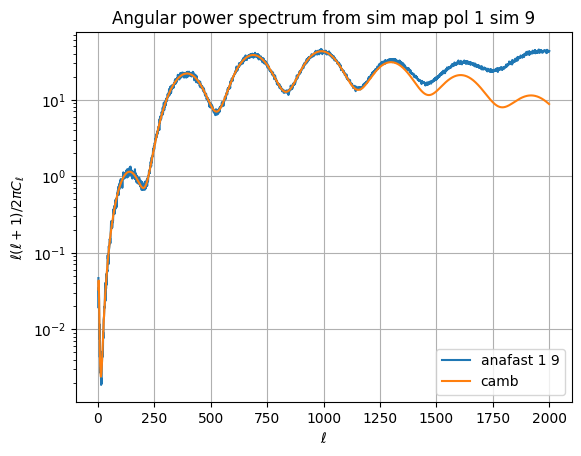

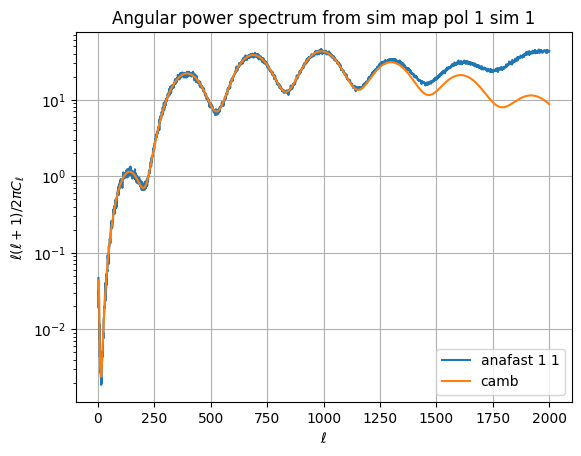

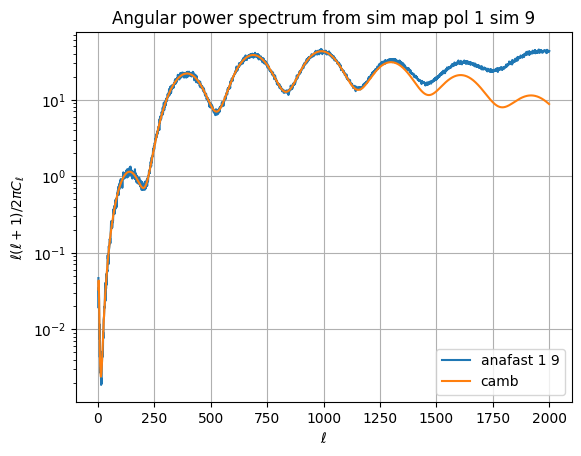

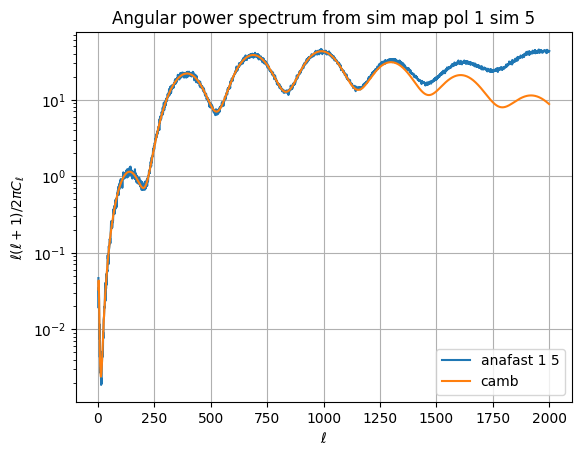

In [298]:
for pol, sim, patch in random_indices:
    plt.figure()
    cl = hp.anafast(maps[pol, sim], lmax=lmax, pol=pol_b, use_pixel_weights=True)
    ell = np.arange(len(cl1))

    scale = (ell * (ell + 1) / 2 / np.pi)[2:]

    plt.semilogy(ell[2:], scale * cl[2:], label=f'anafast {pol} {sim}')
    plt.semilogy(camb_ls, camb_ls * (camb_ls + 1) / 2 / np.pi * camb_cls[:, pol], label='camb')

    plt.xlabel("$\ell$")
    plt.ylabel("$\ell(\ell+1)/2\pi C_{\ell}$")
    plt.title(f'Angular power spectrum from sim map pol {pol} sim {sim}')
    plt.legend()
    plt.grid()
    plt.show()

In [299]:
# beam = lambda alm : alm
# icov_nl = data.icov_diag_nonlensed
# icov_ell = np.ones((1, lmax + 1))
# estimator = KSW(cosmo.red_bispectra, icov_nl, beam, lmax, polarizations)

# for pol, sim, patch in random_indices:
#     alm = hp.map2alm(maps[pol,sim], lmax=lmax, use_pixel_weights=True)[np.newaxis, :]
    
#     # fisher = estimator.compute_fisher_isotropic(icov_ell)
#     # lin_term = estimator.compute_linear_term(alm.copy(), no_icov=True)
#     # print(fisher, lin_term)

#     # print(alm.shape)
#     estimator.step(alm.copy())
#     print('fnl estimate', estimator.compute_estimate(alm))

# Goodbye